# Linear Interface, Structured Mesh
- the most basic test case: method must be exact

In [1]:
import ddr_tools as ddr #custom module
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact #interactive plots
import os
from matplotlib import ticker
from matplotlib.patches import Polygon
from matplotlib.collections import PolyCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import NullFormatter
import meshio
from scipy.sparse.linalg import gmres

function to load mesh is adjuted to take into account a structured mesh

In [2]:
def load_square_struc_mesh(filename):
    """
    Loads and parses a 2D mesh in msh format

    Parameters:
    - filename: path to the mesh file

    Returns:
    - Mesh object
    """
    # LOAD MESH:
    mesh_file_path = filename
    mesh = meshio.read(mesh_file_path)
    # face2node connectivity
    faces = mesh.cells[2].data # for structured cell2node is the 3rd field ""
    # node coordinates
    coords = mesh.points
    # Add dummy column to host faces with more than 3 vertices
    faces = np.c_[faces, -1*np.ones(faces.shape[0])]
    faces = faces.astype(int)
    # Sizes
    Nfaces_init = faces.shape[0]
    Npoints_init = coords.shape[0]
    Nfaces = Nfaces_init
    Npoints = Npoints_init
    # Mask for elements: 0 if uncut, 1 if cut, 2 if generated by cut
    cut_faces = np.zeros(Nfaces)
    # gamme_edge2face connectivity is created by function break_mesh
    # in/ex mask (0: in, 1: ex, -1: cut cell)
    side_mask = -1*np.ones(Nfaces)
    # boundary mask, code:
    # 0: internal
    # 1: x=-0.5
    # 2: y=-0.5
    # 3: x= 0.5
    # 4: y= 0.5
    bnd_mask = np.zeros(Npoints_init)
    return ddr.Mesh (faces, Nfaces, Nfaces_init, coords, Npoints, Npoints_init, cut_faces, side_mask, bnd_mask)


data: currently with a jump

In [3]:
# data 
L = 0.5 # semi-side
sigma_min = 0.1
sigma_plus = 1
phi_datum = lambda x,y: 0.5 # have to define it as lambda function and as real
phi_gamma = 0.5
g_min  = -1
g_plus =  1
    
A_min  = sigma_plus/(sigma_plus+sigma_min)*(g_plus-g_min-phi_gamma)/L
A_plus = sigma_min/sigma_plus*A_min
B_min  = g_min+A_min*L
B_plus = g_plus-A_plus*L

# ref sol: expressions in x,y 
ref_sol_min = lambda x,y: A_min*(x+L)+g_min
ref_sol_plus = lambda x,y: A_plus*(x-L)+g_plus
# ref_sol_plus = lambda x,y: ref_sol_min(x,y) # when solution is linear

# wrapper ref sol that can be called by ref_sol(mesh,ino)
ref_sol = lambda mesh, dof, \
          ref_sol_min=ref_sol_min, ref_sol_plus=ref_sol_plus: \
          ddr.reference_1D_solution(mesh, dof, ref_sol_min, ref_sol_plus) 

eta = 1e4

- $M_\Gamma$ is taken with + sign beacuse nrmal is from in to ex in this case
- $S*u$ should be 0 because solution is linear so reconstruction is exact
- $N_\Gamma*u - b$ should be 0 if jump is well-imposed

In [4]:
# CONVERGENCE STUDY: Solve problem for each mesh in the sequence and record error 
size_list = [5, 10, 20]
mesh_filenames = ["square_struc_L1_N"+str(size)+".msh" for size in size_list]
Meshes = []
G_matrices = []
G_no_sigma_matrices = []
S_matrices =[]
M_gamma_matrices = []
N_gamma_matrices = []
b_phi_vectors = []
A_matrices = []
b_vectors = []
solutions = []
errors_L0 = []
errors_energy = []
solution_filenames = ["square_struc_L1_N"+str(size)+".vtk" for size in size_list]

tolerance = 1e-20 # imposed tolerance for linear solver

for (i,N) in enumerate (size_list):
    
    # load mesh
    mesh = load_square_struc_mesh(mesh_filenames[i]) # adapted for structured mesh
    # move critical points near the interface
    ddr.move_critical_points_1D(mesh) # OK
    # break mesh
    ddr.break_mesh_1D(mesh) # OK
    # mark boundaries
    ddr.mark_bnd_points(mesh) # OK
    # assemble system
    G = ddr.assemble_G(mesh, sigma_min,sigma_plus) # OK
    G_no_sigma = ddr.assemble_G_no_sigma(mesh) # OK
    S = ddr.assemble_S(mesh) # OK
    M_gamma = ddr.assemble_M_gamma(mesh,sigma_min,sigma_plus)
    N_gamma = ddr.assemble_N_gamma(mesh)
    b_phi = ddr.assemble_b_phi(mesh,phi_datum)
    # define system, apply bc conds an solve
    A =  G+S+eta*N_gamma +np.transpose(M_gamma)
    b = eta*b_phi
    [A, b] = ddr.impose_bc(mesh, A, b, ref_sol)
    # impose also bnd conds to each of matrices
    [N_gamma, b_gamma] = ddr.impose_bc(mesh, N_gamma, b_phi, ref_sol)
    # solve using gmres at fixed tolerace
    u, info = gmres(A, b, tol=tolerance)
    print ("Residuals: ", "S ", np.max(np.abs(np.dot(S,u))), \
                          "N_gamma ", np.max(np.abs(np.dot(N_gamma,u)-b_gamma)), \
                          "total ", np.max(np.abs(np.dot(A,u)-b)))
    # write solution
    ddr.write_VTK_file(mesh, u, solution_filenames[i])
    # calculate error
    err_L0 = ddr.calc_L0_error(mesh, u, ref_sol)
    err_energy = ddr.calc_energy_error(mesh, u, ref_sol, G_no_sigma, N_gamma, S)
    # register 
    Meshes.append(mesh)
    G_matrices.append(G)
    G_no_sigma_matrices.append(G_no_sigma)
    S_matrices.append(S)
    M_gamma_matrices.append(M_gamma)
    N_gamma_matrices.append(N_gamma)
    b_phi_vectors.append(b_phi)
    A_matrices.append(A)
    b_vectors.append(b)
    solutions.append(u)
    errors_L0.append(err_L0)
    errors_energy.append(err_energy)

Residuals:  S  2.2100377083944522e-15 N_gamma  2.0816681711721685e-17 total  2.8421709430404007e-13
Residuals:  S  4.88498130835069e-15 N_gamma  1.0408340855860843e-17 total  1.4210854715202004e-13
Residuals:  S  7.577272143066693e-15 N_gamma  8.673617379884035e-18 total  8.526512829121202e-14


In [5]:
# Residuals calculated on the exact solution 
n = 0

mesh = Meshes[n]
G = G_matrices[n]
M_gamma = M_gamma_matrices[n]
N_gamma = N_gamma_matrices[n]
S = S_matrices[n]
A = A_matrices[n]
b_phi = b_phi_vectors[n]
b = b_vectors[n]

u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)] 

print ("Residuals:", "\nS ", np.max(np.abs(np.dot(S,u_ref))), \
                     "\n(M_gamma ", np.max(np.abs(np.dot(M_gamma,u_ref))),")" \
                     "\nN_gamma ", np.max(np.abs(np.dot(N_gamma,u_ref)-b_phi)), \
                     "\ntotal ", np.max(np.abs(np.dot(A,u_ref)-b)))

Residuals: 
S  8.326672684688674e-17 
(M_gamma  0.5000000000000004 )
N_gamma  6.245004513516506e-17 
total  4.547473508864641e-13


Error appears to be driven by potential reconstruction; jump is well imposed

[0.28020954 0.66175316]


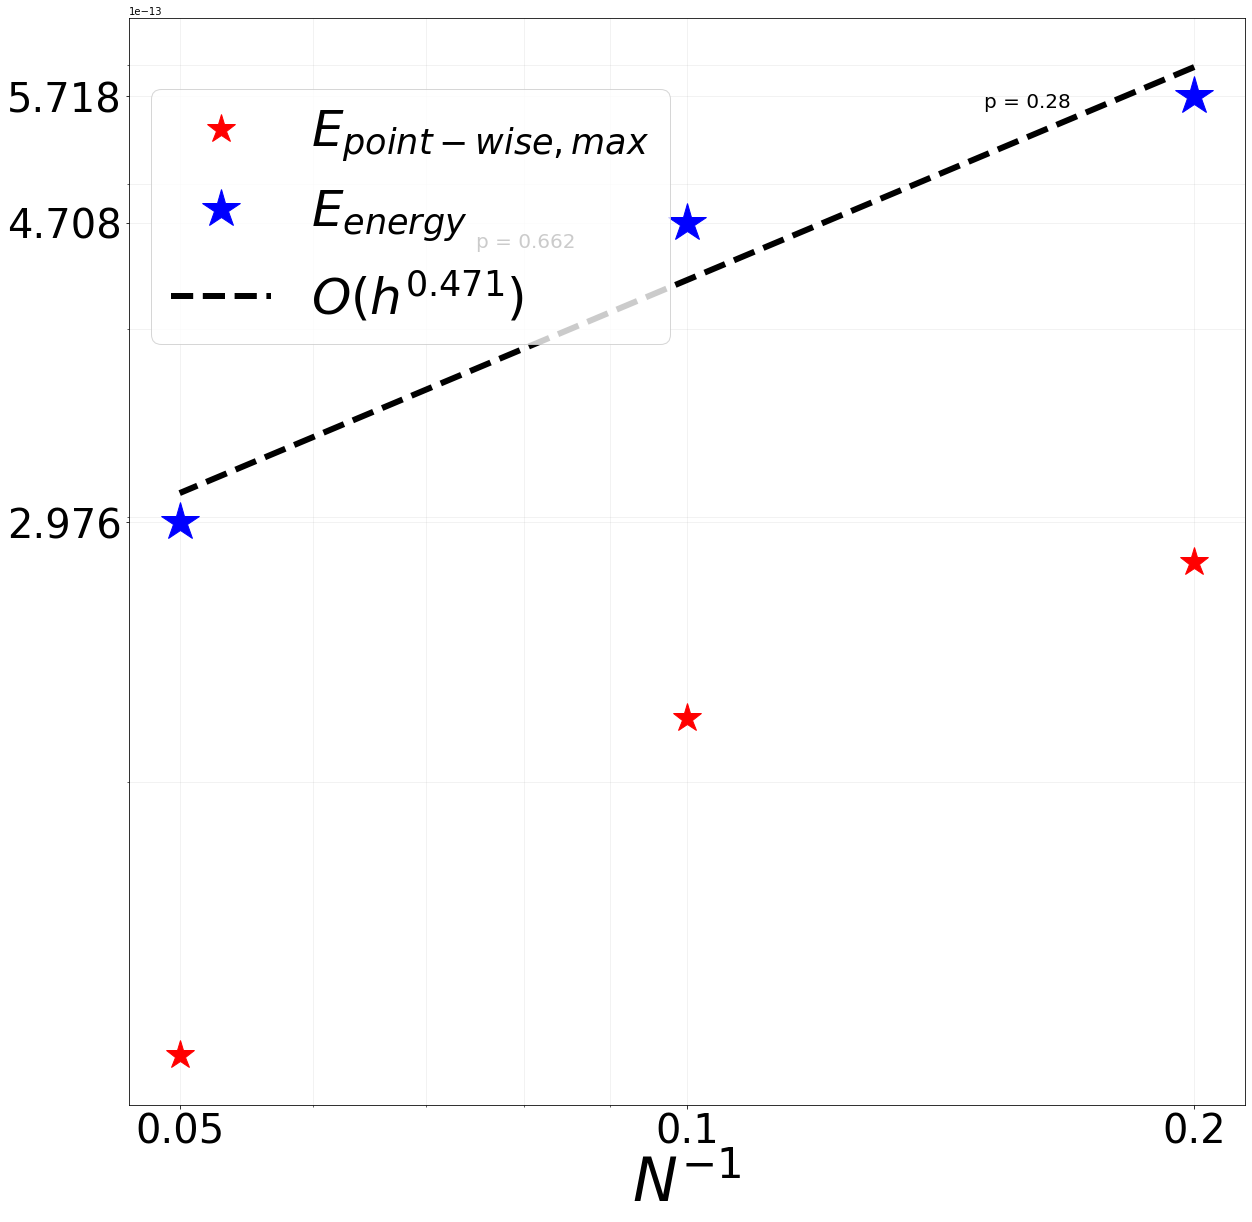

In [6]:
legend_size = 60
label_size = 40
fig_size = 20
line_width = 6
axis_name_size = 60
marker_size = 30

N = len(size_list)
fig,ax = plt.subplots(figsize=(fig_size,fig_size))
h = [1/N for N in size_list]
h_sq = [k*k for k in h]


solutions_ref = [np.array([ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]) for mesh in Meshes]
#errors_L2 = [np.linalg.norm(u-u_ref)/u.shape[0] for (u, u_ref) in zip(solutions, solutions_ref)]

orders = (np.log(errors_energy[1:])-np.log(errors_energy[0:N-1]))/ (np.log(h[1:])-np.log(h[0:N-1]))


ax.loglog(h,errors_L0, '*', label="$E_{point-wise,max}$", markersize = marker_size, color="red")
ax.loglog(h,errors_energy, '*', label="$E_{energy}$", markersize = marker_size+10, color="blue")
#ax.loglog(h,errors_L2, '*', label="$E_{L2}$", markersize = marker_size, color="green")
#ax.loglog(h,h/np.mean(h)*np.mean(errors_energy),'--', label="$O(N^{-1})$", color="black", linewidth= line_width )
#ax.loglog(h,h_sq/np.mean(h)*np.mean(errors_energy),'--', label="$O(N^{-2})$", color="black", linewidth= line_width )
# estimate and plot order of convergence
orders = (np.log(errors_energy[1:])-np.log(errors_energy[0:N-1]))/ (np.log(h[1:])-np.log(h[0:N-1]))
p = np.mean(orders)
h_p = [np.power(k,p) for k in h]
ax.loglog(h,h_p/np.mean(h_p)*np.mean(errors_energy),'--', label="$O(h^{"+str(np.round(p,3))+"})$", color="black", linewidth= line_width )
# print 
for i in range(len(size_list)-1):
    text = "p = "+str(np.round(orders[i],3))
    pos_x = 0.5*(h[i+1]+h[i])
    pos_y = 0.5*(errors_energy[i+1]+errors_energy[i]) - 0.4*(errors_energy[i+1]-errors_energy[i])
    ax.text(pos_x, pos_y, text, fontsize=20, color='black')

# Customize tick formatting
#plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().xaxis.set_major_locator(ticker.FixedLocator(h))
plt.gca().xaxis.set_minor_formatter(NullFormatter())
plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().yaxis.set_minor_formatter(NullFormatter())

# Set the ticks at each data point
plt.xticks(h,h)
plt.yticks(errors_energy) 

#ax.get_xaxis().get_major_formatter().labelOnlyBase = False
ax.tick_params(axis='x', which='both', labelsize=label_size)
ax.tick_params(axis='y', which='both', labelsize=label_size)
ax.set_xticks(h)

#grid
ax.grid(alpha=0.2,which='both')

# legend and axis label
legend = ax.legend(prop={'size': legend_size-10},loc=(0.02,0.7)) 
ax.set_xlabel('$N^{-1}$',fontsize=axis_name_size)
#ax.set_ylabel('$$',fontsize=axis_name_size) 
# tick setting

#plt.show()
plt.savefig('L0_convergence.png')
ax.grid('on')

print (orders)

# residual is screwed if $\eta$ is too high

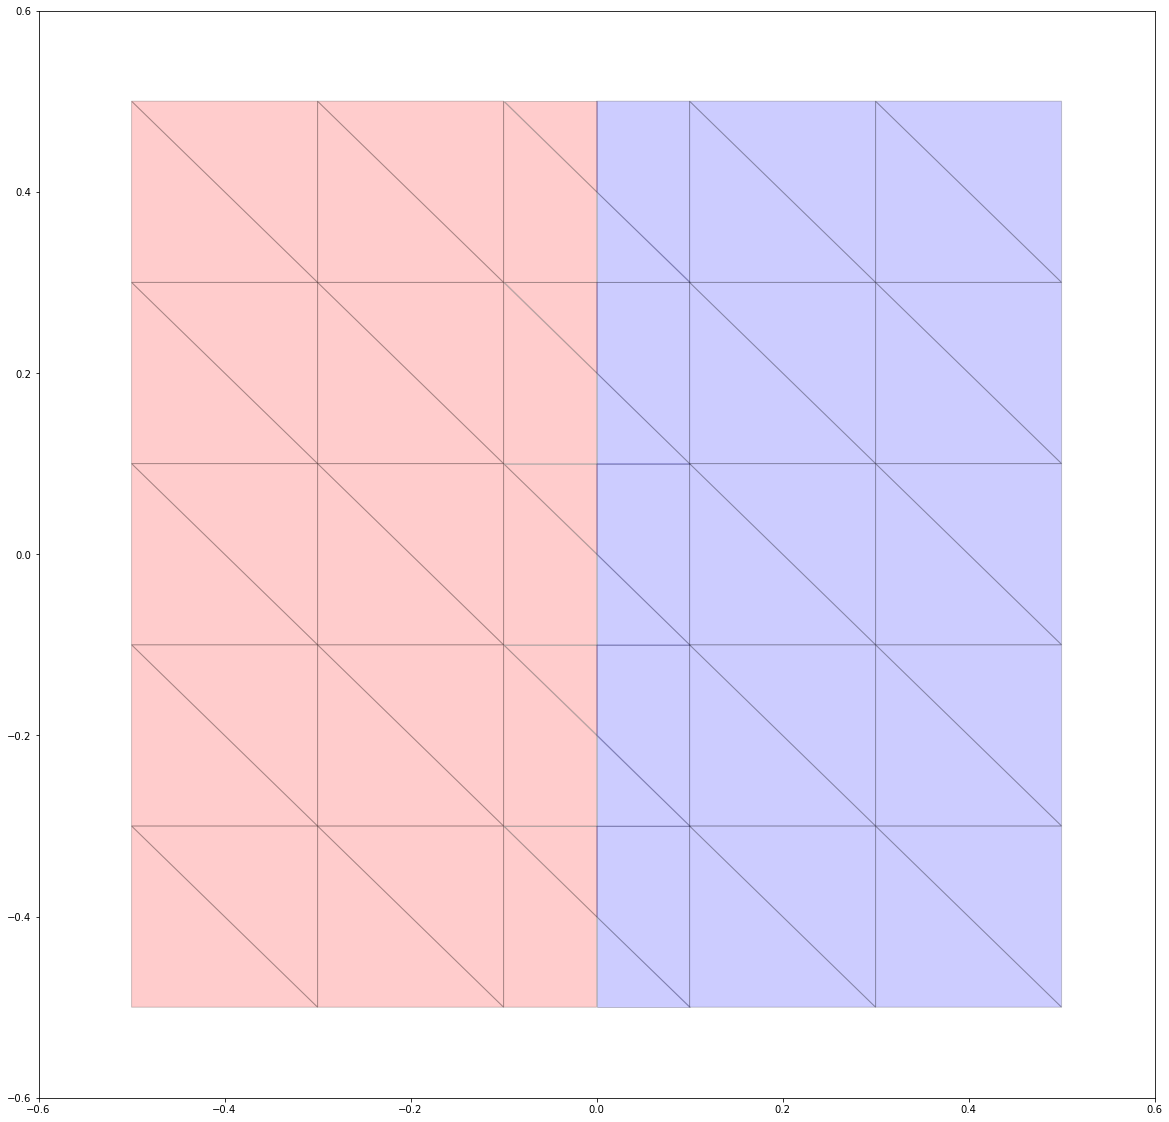

In [7]:
# CHECK MESH

def check_mesh(mesh):
    fig, ax = plt.subplots(figsize=(20,20))
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(-0.6, 0.6)
    # trace underlying mesh 
    for ifa in range(mesh.Nfaces):
        verts = []
        if (mesh.cut_faces[ifa]!=1):
            # determine number of vertices
            if (mesh.faces[ifa,3]==-1):
                nvert = 3
            else:
                nvert = 4
            if (mesh.cut_faces[ifa]==0):
                nvert = 3
            # determine side    
            if (mesh.side_mask[ifa]==0):
                color = 'red'
                #color = 'white'
            elif (mesh.side_mask[ifa]==1):
                color = 'blue'
                #color = 'white'
            else:
                color = 'green'
                #color = 'white'
            for ino in range(nvert):
                p1 = mesh.coords[mesh.faces[ifa,ino],:]
                verts.append(p1[0:2])
            element = Polygon(verts, closed=True, edgecolor='black', facecolor=color, alpha=0.2)
            ax.add_patch(element)
    for (ie, couple) in enumerate(mesh.gamma_edges):
        ifa1 = couple[0]
        ifa2 = couple[1]
        text_pos_1 = ddr.barycenter(mesh, ifa1)
        text_pos_2 = ddr.barycenter(mesh, ifa2)
        text_content_1= str(ie)+"_min"
        text_content_2= str(ie)+"_plus"
        #ax.text(text_pos_1[0], text_pos_1[1], text_content_1, fontsize=20, color='black')
        #ax.text(text_pos_2[0], text_pos_2[1], text_content_2, fontsize=20, color='black')
        
n=0
mesh = Meshes[n]
check_mesh(mesh)

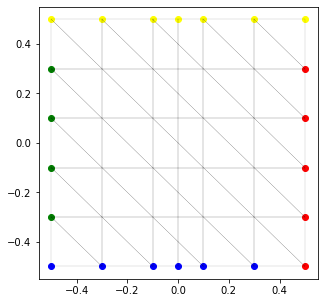

In [8]:
# CHECK BOUNDARY MASK

def visualize_bnd_points_with_dof(mesh):
    fig, ax = plt.subplots(figsize=(5,5))
    for ifa in range(mesh.Nfaces):
        if (mesh.cut_faces[ifa]!=1):
            if (mesh.faces[ifa,3]==-1):
                nvert = 3
            else:
                nvert = 4
            for ino in range(nvert):
               p1 = mesh.coords[mesh.faces[ifa,ino],:]
               p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
               dx = p2-p1
               xx = [p1[0],p2[0]]
               yy = [p1[1],p2[1]]
               ax.plot(xx,yy,'k', linewidth=0.1)
    # mark generated points
    for dof in range(mesh.Npoints):
        if (dof<mesh.Npoints):
            ino = dof
        else:
            ino = dof-(mesh.Npoints-mesh.Npoints_init)
        if (mesh.bnd_mask[ino]>0):
            xx = mesh.coords[ino,0]
            yy = mesh.coords[ino,1]
            if (mesh.bnd_mask[ino]==1):
                point = ax.scatter(xx,yy,color='green')
            if (mesh.bnd_mask[ino]==2):
                point = ax.scatter(xx,yy,color='blue')
            if (mesh.bnd_mask[ino]==3):
                point = ax.scatter(xx,yy,color='red')
            if (mesh.bnd_mask[ino]==4):
                point = ax.scatter(xx,yy,color='yellow')
    
visualize_bnd_points_with_dof(Meshes[n])

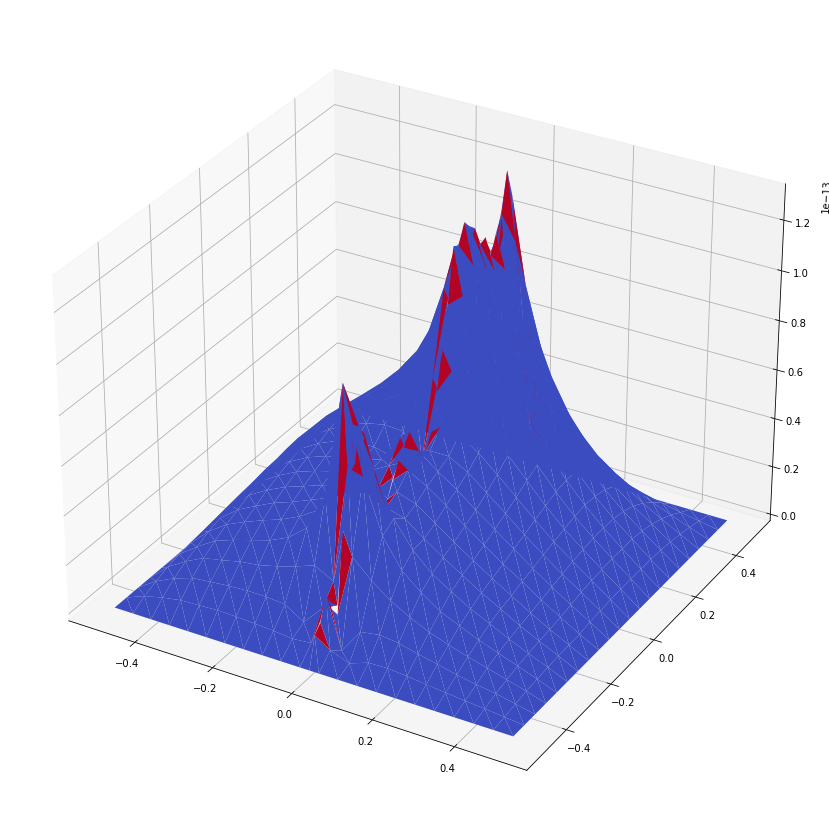

Error:  1.3145040611561853e-13


In [9]:
#VISUALIZATION OF ERROR
n = 2
mesh = Meshes[n]
u = solutions[n]
u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]

# define u_ref exactely as done in routine impose_bc
#def def_u_ref (mesh,u_ref, ref_sol):
#    for dof in range(mesh.Ndof):
#        if (dof<mesh.Npoints):
#            ino = dof
#        else:
#            ino = dof-(mesh.Npoints-mesh.Npoints_init)
#        if (mesh.bnd_mask[ino]>0):
#            u_ref[dof] = ref_sol(mesh,dof)
#u_ref = np.zeros(mesh.Ndof)
#def_u_ref(mesh, u_ref, ref_sol)        

ddr.plot_solution(mesh, np.abs(u_ref-u), elevation=30, azimuth=-60)
print ("Error: ", ddr.calc_L0_error(mesh,u,ref_sol))


- errore è concentrato all'interfaccia, cattivo segno (ma in realtà è dovuto agli errori nella ricostruzione)
- errore è molto basso, e dipende da $\eta$ (ma perché il condizonamento e quind il residuo dipende da $\eta$)

L'errore è più o meno dell'ordine del residuo. La tolleranza negli operatori locali non è settata (ho provato, ma l'errore faceva robe strane)

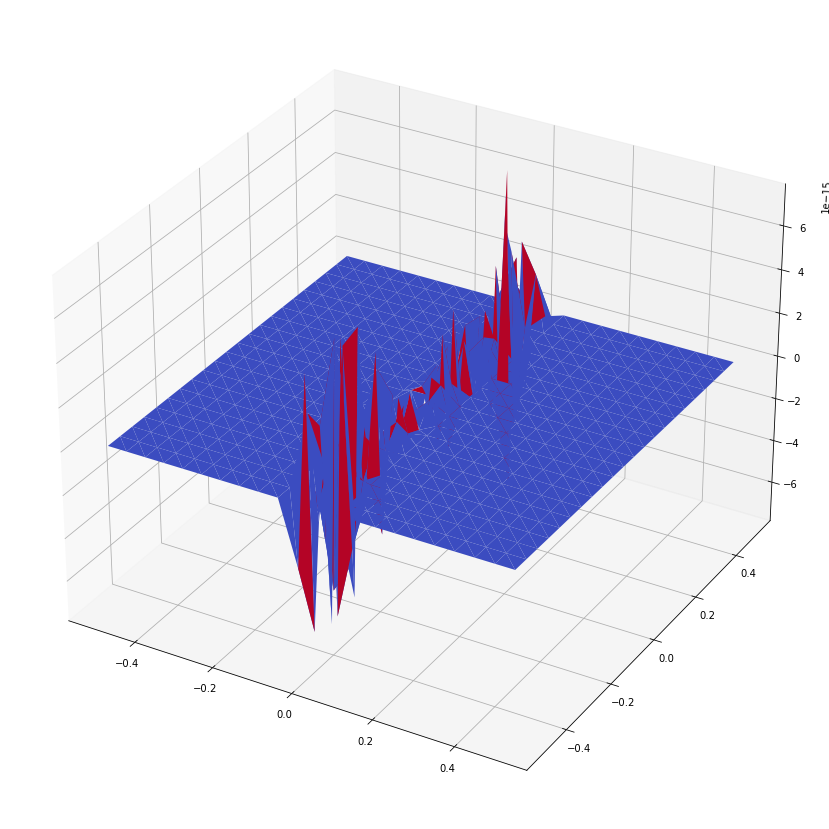

Error:  7.577272143066693e-15


In [10]:
# CHECK POTENTIAL RECONSTRUCTION 
n = 2
mesh = Meshes[n]
u = solutions[n]
S = S_matrices[n]       

ddr.plot_solution(mesh, np.dot(S,u), elevation=30, azimuth=-60)
print ("Error: ", np.max(np.abs(np.dot(S,u))))


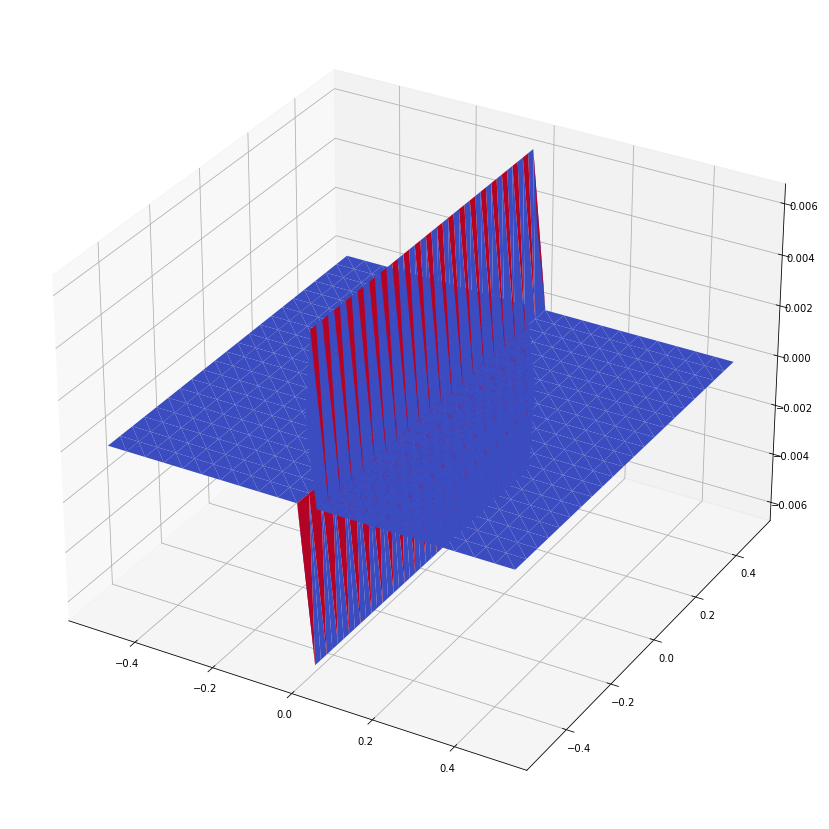

max:  0.006493506493516044 min:  -0.006493506493516099 ref:  0.006818181818181818


In [11]:
# CHECK M_gamma
n = 2
mesh = Meshes[n]
u = solutions[n]
M_gamma = M_gamma_matrices[n]       

ddr.plot_solution(mesh, np.dot(np.transpose(M_gamma),u), elevation=30, azimuth=-60)

mean = 0.5*(sigma_min*A_min+sigma_plus*A_plus)
E = 0.5*(1/size_list[n])

print ("max: ", np.max(np.dot(np.transpose(M_gamma),u)),\
       "min: ", np.min(np.dot(np.transpose(M_gamma),u)),\
       "ref: ", E*mean )

13 7.777112287499222e-14 0.29870129870129847 1.0
14 2.3647750424515834e-13 0.8701298701298701 1.0
15 3.1308289294429414e-14 0.8831168831168831 1.0
18 9.992007221626409e-16 0.922077922077922 1.0
20 4.551914400963142e-15 0.948051948051948 1.0
21 3.6637359812630166e-15 0.961038961038961 1.0
23 1.2212453270876722e-15 0.987012987012987 1.0
29 8.881784197001252e-16 1.0 1.0
31 4.440892098500626e-15 1.0 1.0
33 4.884981308350689e-15 1.0 1.0
42 1.6653345369377348e-15 1.0 1.0
53 2.5091040356528538e-14 0.8701298701298701 1.0
54 5.551115123125783e-16 0.29870129870129847 1.0
484 4.318767565791859e-14 0.36363636363636354 1.0
526 1.6653345369377348e-16 0.36363636363636354 1.0
484 4.318767565791859e-14 0.8636363636363636 1.0


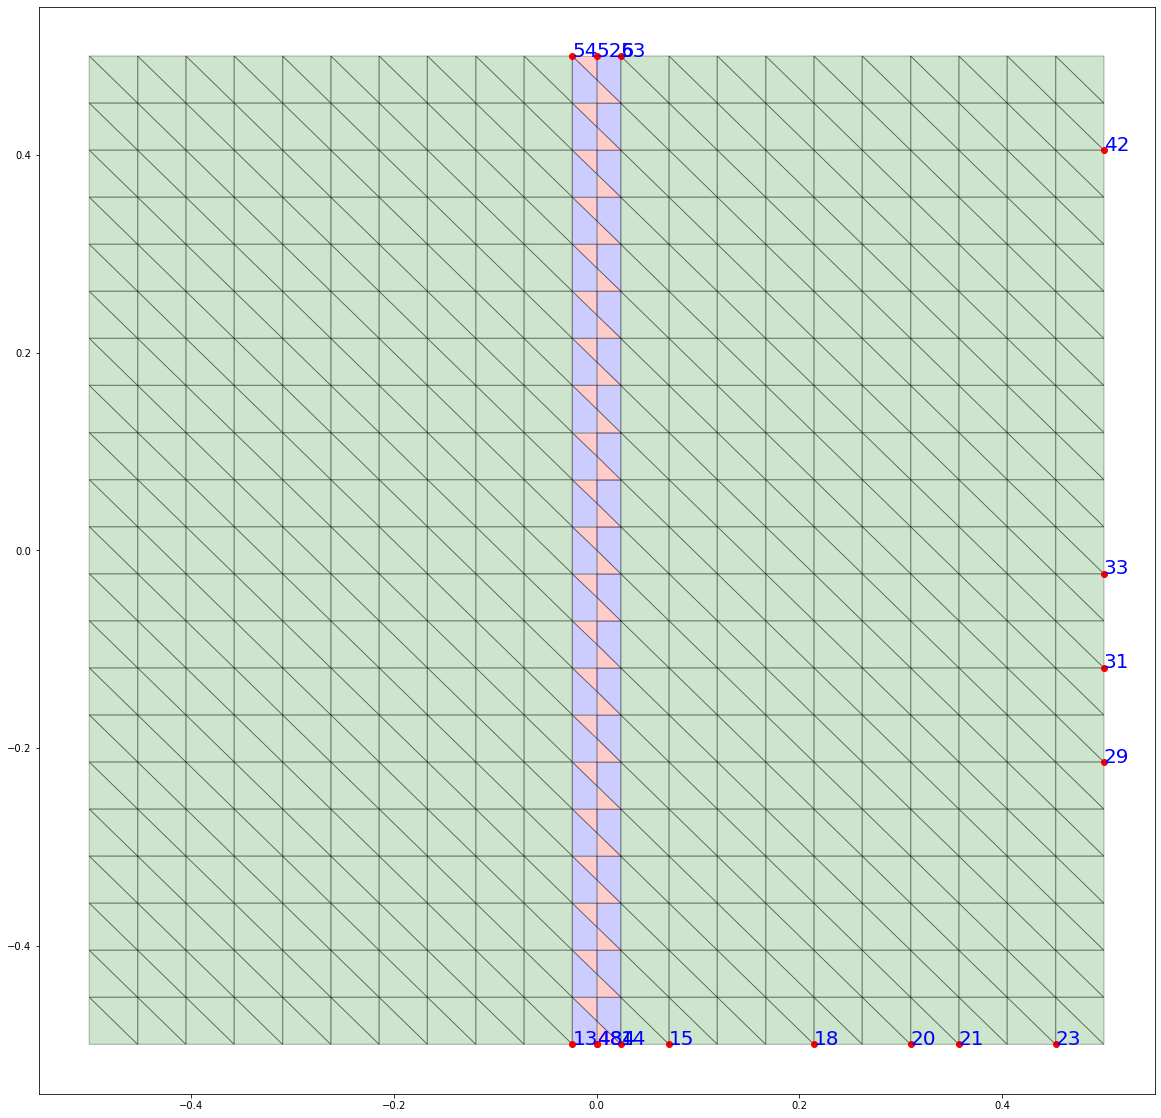

In [19]:
def check(mesh,u, u_ref, b, A):
    fig, ax = plt.subplots(figsize=(20,20))
    # trace underlying mesh 
    for ifa in range(mesh.Nfaces):
        verts = []
        if (mesh.cut_faces[ifa]!=1):
            if (mesh.faces[ifa,3]==-1):
                nvert = 3
                color = 'red'
            else:
                nvert = 4
                color = 'blue'
            if (mesh.cut_faces[ifa]==0):
                nvert = 3
                color = 'green'
            for ino in range(nvert):
               p1 = mesh.coords[mesh.faces[ifa,ino],:]
               p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
               verts.append(p1[0:2])
               dx = p2-p1
               xx = [p1[0],p2[0]]
               yy = [p1[1],p2[1]]
               ax.plot(xx,yy,'k', linewidth=0.1)
            element = Polygon(verts, closed=True, edgecolor='black', facecolor=color, alpha=0.2)
            ax.add_patch(element)
    # spot problematic points
    for dof in range(mesh.Ndof):
        if (dof<mesh.Npoints):
            ino = dof
        else:
            ino = dof-(mesh.Npoints-mesh.Npoints_init)
        if (mesh.bnd_mask[ino]>0):
            if (abs(u[dof]-u_ref[dof])>0):
                    print (ino, abs(u[ino]-u_ref[ino]), b[dof], A[dof,dof])
                    text_position = mesh.coords[ino,:]
                    text_content_1 = str(b[dof])
                    text_content_2 = str(ino)
                    text_content_3 = str(A[dof,dof])
                    xx = mesh.coords[ino, 0]
                    yy = mesh.coords[ino, 1]
                    #ax.text(xx, yy, text_content_1, fontsize=20, color='red')
                    ax.text(xx, yy, text_content_2, fontsize=20, color='blue')
                    point = ax.scatter(xx,yy,color='red')

b = b_vectors[n]
A = A_matrices[n]
check(mesh, u, u_ref, b, A)

Checking $M_\Gamma$: visualize on mesh normals etc to spot sign errors

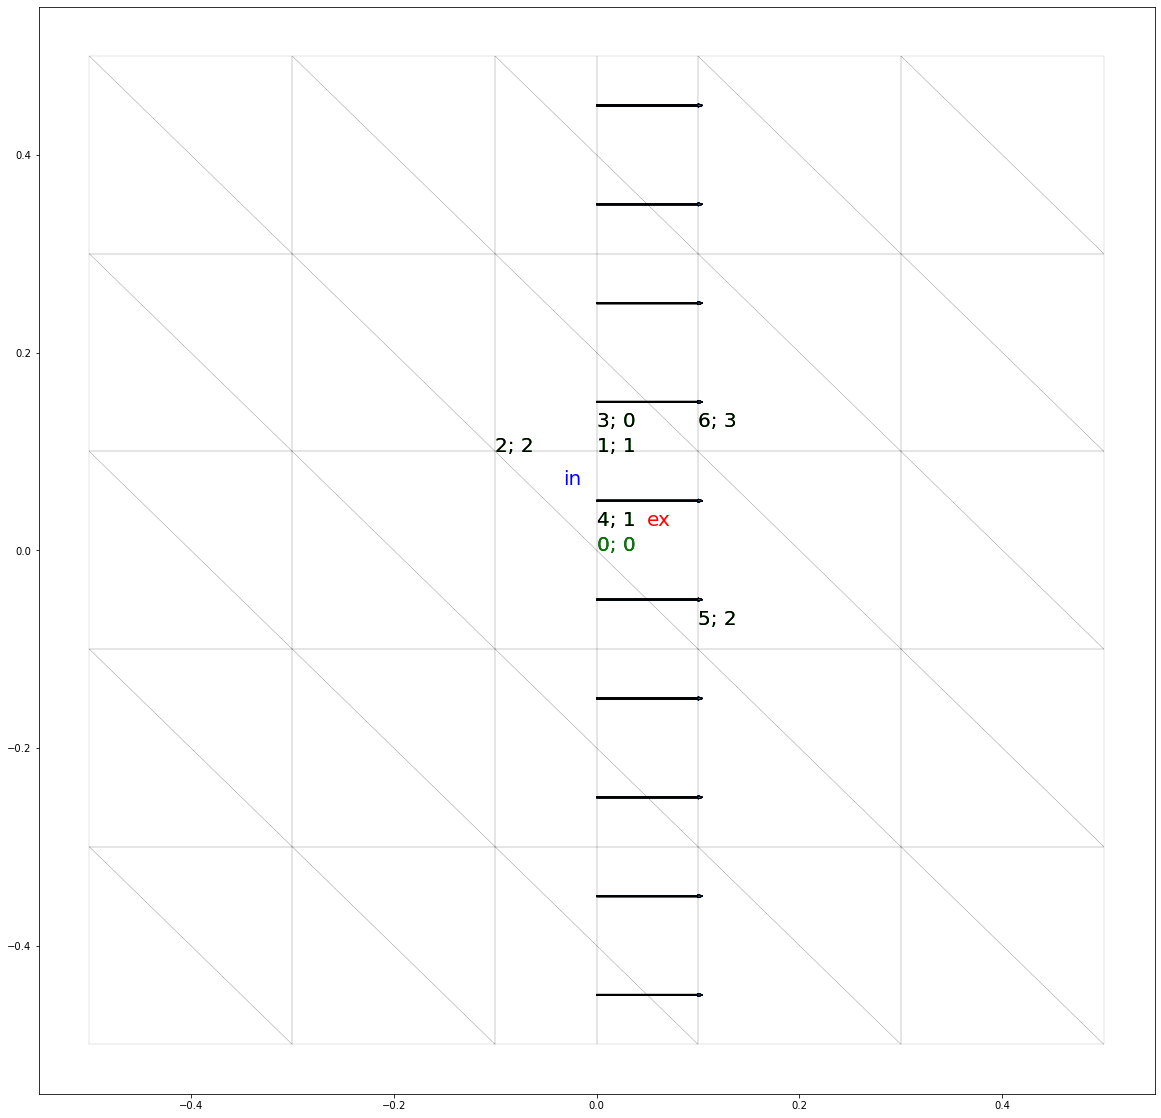

In [82]:
def assemble_M_gamma(mesh,sigma_in,sigma_ex):
    to_check = 5
    fig, ax = plt.subplots(figsize=(20,20))
    # visualize underlying mesh#####################################
    for ifa in range(mesh.Nfaces):
        if (mesh.cut_faces[ifa]!=1):
            if (mesh.faces[ifa,3]==-1):
                nvert = 3
            else:
                nvert = 4
            for ino in range(nvert):
               p1 = mesh.coords[mesh.faces[ifa,ino],:]
               p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
               dx = p2-p1
               xx = [p1[0],p2[0]]
               yy = [p1[1],p2[1]]
               ax.plot(xx,yy,'k', linewidth=0.1)
    #################################################################
    # Matrix M_gamma (jump of gradient)
    M_gamma = np.zeros((mesh.Ndof,mesh.Ndof))
    for ied in range(mesh.gamma_edges.shape[0]):
        # table of dofs touched by the edge
        # 7 dofs: 3 from the triangle + 4 from the quad
        edge_dofs = np.zeros((7,2),dtype=int)
        ifa_in = mesh.gamma_edges[ied,0]
        ifa_ex = mesh.gamma_edges[ied,1]
        node_per_face_in = np.count_nonzero(mesh.faces[ifa_in,:] != -1)
        node_per_face_ex = np.count_nonzero(mesh.faces[ifa_ex,:] != -1)
        if (ied==to_check):
            # show two faces ###################################
            pos_ifa_in = ddr.barycenter(mesh,ifa_in)
            pos_ifa_ex = ddr.barycenter(mesh,ifa_ex)
            ax.text(pos_ifa_in[0], pos_ifa_in[1], "in", fontsize=20, color='blue')
            ax.text(pos_ifa_ex[0], pos_ifa_ex[1], "ex", fontsize=20, color='red')
            ####################################################
        # dofs ifa_in
        for ino_in in range(node_per_face_in):
            edge_dofs[ino_in,0] = ddr.glob_idx(mesh,ifa_in, ino_in)
            edge_dofs[ino_in,1] = ifa_in
        # dofs ifa_ex
        for ino_ex in range(node_per_face_ex):
            edge_dofs[node_per_face_in+ino_ex,0] = ddr.glob_idx(mesh,ifa_ex, ino_ex)
            edge_dofs[node_per_face_in+ino_ex,1] = ifa_ex
        for idof1 in range(7):
            dof1 = edge_dofs[idof1,0] #global idx
            if (idof1<node_per_face_in): #local idx
                dof1_loc = idof1
            else:
                dof1_loc = idof1-node_per_face_in
            ifa1 = edge_dofs[idof1,1] #idx of face$
            # Show dofs############################################################
            if (ied==to_check):
                if (dof1<mesh.Npoints):
                    ino = dof1
                else:
                    ino = dof1 - (mesh.Npoints-mesh.Npoints_init)
                text_pos= mesh.coords[ino,0:2]+np.array([0,0.025])*(ifa1==ifa_ex)
                text = str(idof1)+"; "+str(dof1_loc)
                ax.text(text_pos[0], text_pos[1], text, fontsize=20, color='black')
            ########################################################################
            GR1 = ddr.GR(mesh,ifa1)
            sigma1 = sigma_in*int(ifa1==ifa_in) + sigma_ex*int(ifa1==ifa_ex)
            tangent = mesh.coords[mesh.faces[ifa1,1],0:2]-mesh.coords[mesh.faces[ifa1,0],0:2]
            sign1 = int(ifa1==ifa_in)-int(ifa1==ifa_ex)
            normal = sign1*np.array([[0,1],[-1,0]])@tangent
            # add it to plot
            midpoint  = 0.5*(mesh.coords[mesh.faces[ifa1,1],0:2]+mesh.coords[mesh.faces[ifa1,0],0:2])
            ax.arrow(midpoint[0],midpoint[1],normal[0],normal[1])
            #
            mean_sigma_grad_normal = 0.5*sigma1*np.dot(GR1[:,dof1_loc],normal)
            for idof2 in range(7):
                dof2 = edge_dofs[idof2,0] #global idx
                if (idof2<node_per_face_in): #local idx
                    dof2_loc = idof2
                else:
                    dof2_loc = idof2-node_per_face_in
                ifa2 = edge_dofs[idof2,1]
                R2 = ddr.recpot(mesh,ifa2)
                # Show dofs###########################################################
                if (ied==to_check and idof1==0):
                    if (dof2<mesh.Npoints):
                        ino = dof2
                    else:
                        ino = dof2 - (mesh.Npoints-mesh.Npoints_init)
                    text_pos= mesh.coords[ino,0:2]+np.array([0,0.025])*(ifa2==ifa_ex)
                    text = str(idof2)+"; "+str(dof2_loc)
                    ax.text(text_pos[0], text_pos[1], text, fontsize=20, color='green')
                #######################################################################
                ## Setting node prec as first vertex and node post as second
                ## should be indifferent though
                node_per_face_2 = np.count_nonzero(mesh.faces[ifa2,:] != -1)
                if (node_per_face_2 ==4):
                    v2A = R2[0,dof2_loc]
                    v2B = R2[1,dof2_loc]
                else:
                    v2A = R2[1,dof2_loc]
                    v2B = R2[0,dof2_loc]
                # sign (jump must be ex-in)
                sign2 = int(ifa2==ifa_ex)-int(ifa2==ifa_in)
                ## integral
                jump_of_rec = 0.5*(v2A+v2B)*sign2
                M_gamma[dof1,dof2] = M_gamma[dof1,dof2] + mean_sigma_grad_normal*jump_of_rec
        
    return M_gamma                                                                                  
mesh = Meshes[0]
M_gamma_test = assemble_M_gamma(mesh, sigma_min ,sigma_plus)

# WEAK DIRICHLET BOUNDARY CONDITIONS

In [12]:
# data 
L = 0.5 # semi-side
sigma_min = 0.1
sigma_plus = 1
phi_datum = lambda x,y: 0.5 # have to define it as lambda function and as real
phi_gamma = 0.5
g_min  = -1
g_plus =  1
    
A_min  = sigma_plus/(sigma_plus+sigma_min)*(g_plus-g_min-phi_gamma)/L
A_plus = sigma_min/sigma_plus*A_min
B_min  = g_min+A_min*L
B_plus = g_plus-A_plus*L

# ref sol: expressions in x,y 
ref_sol_min = lambda x,y: A_min*(x+L)+g_min
ref_sol_plus = lambda x,y: A_plus*(x-L)+g_plus
# ref_sol_plus = lambda x,y: ref_sol_min(x,y) # when solution is linear

# wrapper ref sol that can be called by ref_sol(mesh,ino)
ref_sol = lambda mesh, dof, \
          ref_sol_min=ref_sol_min, ref_sol_plus=ref_sol_plus: \
          ddr.reference_1D_solution(mesh, dof, ref_sol_min, ref_sol_plus) 

visualization of exact solution

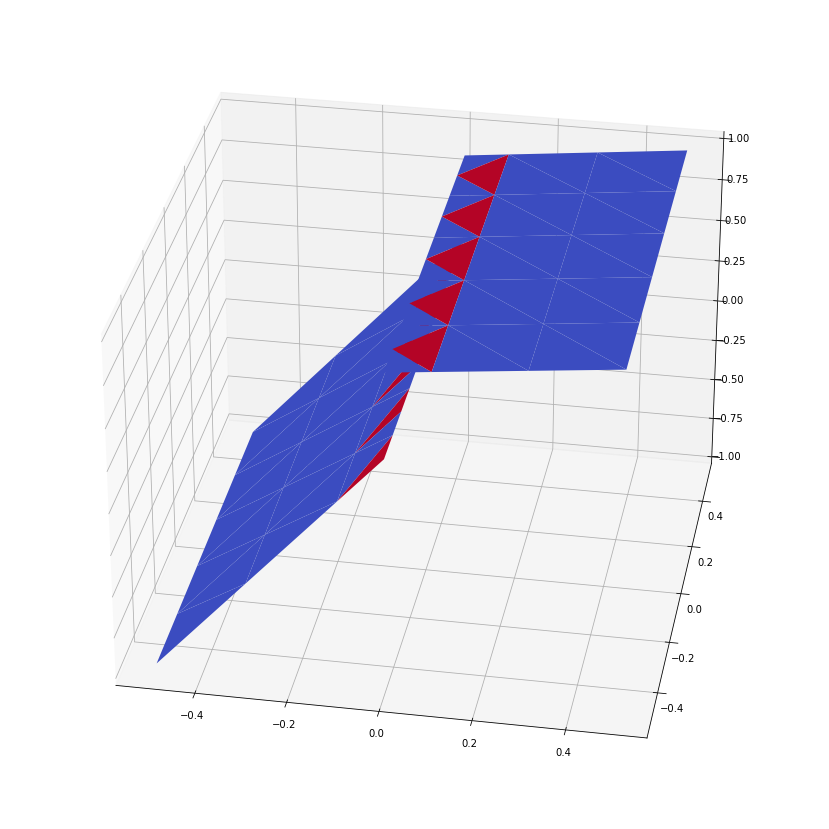

Error:  2.801231469007348e-13


In [13]:
n = 0
mesh = Meshes[n]
u = solutions[n]
u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]      

ddr.plot_solution(mesh, u_ref, elevation=30, azimuth=-80)
print ("Error: ", ddr.calc_L0_error(mesh,u,ref_sol))

In [27]:
# function to create connectivity bnd_edge2[node1,node2]
def create_bnd_connectivity(mesh):
    bnd_edges = []
    for ifa in range(mesh.Nfaces):
        if (mesh.cut_faces[ifa] != 1):
            node_per_face = np.count_nonzero(mesh.faces[ifa,:] != -1)
            for ie in range(node_per_face):
                ino1 = mesh.faces[ifa,ie] # should be counter clockwise
                ino2 = mesh.faces[ifa,(ie+1)%node_per_face]
                if (mesh.bnd_mask[ino1]>0 and mesh.bnd_mask[ino2]>0):
                    edge = np.array([ifa,ie,(ie+1)%node_per_face]) # record face and 2 local dofs
                    bnd_edges.append(edge)

    return bnd_edges

# function to assemble the border flux matrix (not to transpose)
def assemble_FLUX_bnd(mesh, bnd_edges, sigma_min, sigma_plus):
    DIR = np.zeros((mesh.Ndof,mesh.Ndof))
    for ie in range(len(bnd_edges)):
        ifa  = bnd_edges[ie][0]
        locdof1 = bnd_edges[ie][1] # index of node
        locdof2 = bnd_edges[ie][2]
        idof1 = ddr.glob_idx(mesh, ifa, locdof1) # global dof
        idof2 = ddr.glob_idx(mesh, ifa, locdof2)
        ino1 = mesh.faces[ifa, locdof1] # index of node
        ino2 = mesh.faces[ifa, locdof2]
        p1 = mesh.coords[ino1] # point coord
        p2 = mesh.coords[ino2] 
        # fluxes of test functions
        G = ddr.GR(mesh, ifa)
        tangent = p2 - p1
        normal = np.array([[0,1],[-1,0]])@tangent[0:2]
        # sigma
        sigma = sigma_plus+(sigma_min-sigma_plus)*(mesh.side_mask[ifa]==0)
        flux_1 = sigma*np.dot(G[:,locdof1], normal)
        flux_2 = sigma*np.dot(G[:,locdof2], normal)
        DIR[idof1,idof1] = DIR[idof1,idof1] + flux_1*0.5
        DIR[idof1,idof2] = DIR[idof1,idof2] + flux_2*0.5
        DIR[idof2,idof1] = DIR[idof2,idof1] + flux_1*0.5
        DIR[idof2,idof2] = DIR[idof2,idof2] + flux_2*0.5
    return DIR

# function to assemble DIR matrix
def assemble_DIR_matrix(mesh, bnd_edges):
    DIR = np.zeros((mesh.Ndof,mesh.Ndof))
    for ie in range(len(bnd_edges)):
        ifa  = bnd_edges[ie][0]
        locdof1 = bnd_edges[ie][1] # index of node
        locdof2 = bnd_edges[ie][2]
        idof1 = ddr.glob_idx(mesh, ifa, locdof1) # global dof
        idof2 = ddr.glob_idx(mesh, ifa, locdof2)
        ino1 = mesh.faces[ifa,locdof1] # index of node
        ino2 = mesh.faces[ifa,locdof2]
        p1 = mesh.coords[ino1] # point coord
        p2 = mesh.coords[ino2] 
        v1A = 1
        v1B = 0
        v2A = 0
        v2B = 1 # maybe overkill to use calc_r2_prod_integ
        DIR[idof1,idof1] = DIR[idof1,idof1] + ddr.calc_r2_prod_integ(v1A,v1B,v1A,v1B) # notice, it's symmetric
        DIR[idof1,idof2] = DIR[idof1,idof2] + ddr.calc_r2_prod_integ(v1A,v1B,v2A,v2B)
        DIR[idof2,idof1] = DIR[idof2,idof1] + ddr.calc_r2_prod_integ(v2A,v2B,v1A,v1B)
        DIR[idof2,idof2] = DIR[idof2,idof2] + ddr.calc_r2_prod_integ(v2A,v2B,v2A,v2B)
    return DIR

# function to assemble b_g vector
def assemble_b_dir(mesh, bnd_edges, ref_sol):
    b_dir = np.zeros(mesh.Ndof)
    for ie in range(len(bnd_edges)):
        ifa  = bnd_edges[ie][0]
        locdof1 = bnd_edges[ie][1] # local dof
        locdof2 = bnd_edges[ie][2]
        ino1  = mesh.faces[ifa,locdof1] # index of node
        ino2  = mesh.faces[ifa,locdof2]
        idof1 = ddr.glob_idx(mesh, ifa, locdof1) # global dof
        idof2 = ddr.glob_idx(mesh, ifa, locdof2)
        p1 = mesh.coords[ino1] # point coord
        p2 = mesh.coords[ino2]
        v1A = 1
        v1B = 0
        v2A = 0
        v2B = 1 # maybe overkill to use calc_r2_prod_integ
        gA = ref_sol(mesh, idof1)
        gB = ref_sol(mesh, idof2)
        b_dir[idof1] = b_dir[idof1] + ddr.calc_r2_prod_integ(v1A,v1B,gA,gB) # notice, it's symmetric
        b_dir[idof2] = b_dir[idof2] + ddr.calc_r2_prod_integ(v2A,v2B,gA,gB)
    return b_dir

In [29]:
# CONVERGENCE STUDY: Solve problem for each mesh in the sequence and record error 
size_list = [20]
mesh_filenames = ["square_struc_L1_N"+str(size)+".msh" for size in size_list]
Meshes = []
G_matrices = []
G_no_sigma_matrices = []
S_matrices =[]
M_gamma_matrices = []
N_gamma_matrices = []
FLUX_bnd_matrices = []
DIR_matrices = []
b_phi_vectors = []
b_dir_vectors = []
A_matrices = []
b_vectors = []
solutions = []
errors_L0 = []
errors_energy = []
solution_filenames = ["square_struc_L1_N"+str(size)+".vtk" for size in size_list]

eta = 1e4
mu  = 1e4
tolerance = 1e-20 # imposed tolerance for linear solver

for (i,N) in enumerate (size_list):
    
    # load mesh
    mesh = load_square_struc_mesh(mesh_filenames[i]) #OK
    # move critical points near the interface
    ddr.move_critical_points_1D(mesh) # OK
    # break mesh
    ddr.break_mesh_1D(mesh) # OK
    # mark boundaries
    ddr.mark_bnd_points(mesh) # OK
    # create boundary connectivity
    bnd_edges = create_bnd_connectivity(mesh)
    # assemble system
    G = ddr.assemble_G(mesh, sigma_min,sigma_plus) # OK
    G_no_sigma = ddr.assemble_G_no_sigma(mesh) # OK
    S = ddr.assemble_S(mesh) # OK
    M_gamma = ddr.assemble_M_gamma(mesh,sigma_min,sigma_plus)
    N_gamma = ddr.assemble_N_gamma(mesh)
    FLUX_bnd = assemble_FLUX_bnd(mesh, bnd_edges, sigma_min, sigma_plus)
    DIR = assemble_DIR_matrix(mesh, bnd_edges)
    b_phi = ddr.assemble_b_phi(mesh, phi_datum)
    b_dir = assemble_b_dir(mesh, bnd_edges, ref_sol)
    # define system containing weak bnd conds and solve
    A = G+S+eta*N_gamma+np.transpose(M_gamma)-FLUX_bnd+mu*DIR 
    b = eta*b_phi + mu*b_dir
    # solve using gmres at fixed tolerace
    u, info = gmres(A, b, tol=tolerance)
    print ("Residuals: ", "S ", np.max(np.abs(np.dot(S,u))), \
                          "N_gamma", np.max(np.abs(np.dot(N_gamma,u)-b_phi)), \
                          "DIR", np.max(np.abs(np.dot(DIR,u)-b_dir)), \
                          "total ", np.max(np.abs(np.dot(A,u)-b)))
    # write solution
    ddr.write_VTK_file(mesh, u, solution_filenames[i])
    # calculate error
    err_L0 = ddr.calc_L0_error(mesh, u, ref_sol)
    err_energy = ddr.calc_energy_error(mesh, u, ref_sol, G_no_sigma, N_gamma, S)
    # register 
    Meshes.append(mesh)
    G_matrices.append(G)
    G_no_sigma_matrices.append(G_no_sigma)
    S_matrices.append(S)
    M_gamma_matrices.append(M_gamma)
    N_gamma_matrices.append(N_gamma)
    FLUX_bnd_matrices.append(FLUX_bnd)
    DIR_matrices.append(DIR)
    b_phi_vectors.append(b_phi)
    b_dir_vectors.append(b_dir)
    A_matrices.append(A)
    b_vectors.append(b)
    solutions.append(u)
    errors_L0.append(err_L0)
    errors_energy.append(err_energy)

Residuals:  S  5.5213708999551914e-05 N_gamma 2.3694202727284064e-07 DIR 0.0002980842629136671 total  3.5520319270967993e-07


In [34]:
# Residuals calculated on the exact solution 
n = 0

mesh = Meshes[n]
G = G_matrices[n]
M_gamma = M_gamma_matrices[n]
FLUX_bnd = FLUX_bnd_matrices[n]
N_gamma = N_gamma_matrices[n]
S = S_matrices[n]
A = A_matrices[n]
b_phi = b_phi_vectors[n]
b_dir = b_dir_vectors[n]
b = b_vectors[n]

A_alt = G+S+np.transpose(M_gamma)-FLUX_bnd+N_gamma+DIR # as if with eta=1 and \mu=1
b_alt = b_phi + b_dir

u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)] 

print ("Residuals:", "\nS ", np.max(np.abs(np.dot(S,u_ref))), \
                     "\nDIR", np.max(np.abs(np.dot(DIR,u_ref)-b_dir)),\
                     "\nN_gamma ", np.max(np.abs(np.dot(N_gamma,u_ref)-b_phi)), \
                     "\ntotal_bis ", np.max(np.abs(np.dot(A_alt,u_ref)-b_alt)), \
                     "\ntotal ", np.max(np.abs(np.dot(A,u_ref)-b)))

Residuals: 
S  1.6653345369377348e-16 
DIR 4.440892098500626e-16 
N_gamma  5.551115123125783e-17 
total_bis  2.980519480519474 
total  2.9805194805230713


Visualize Residuals

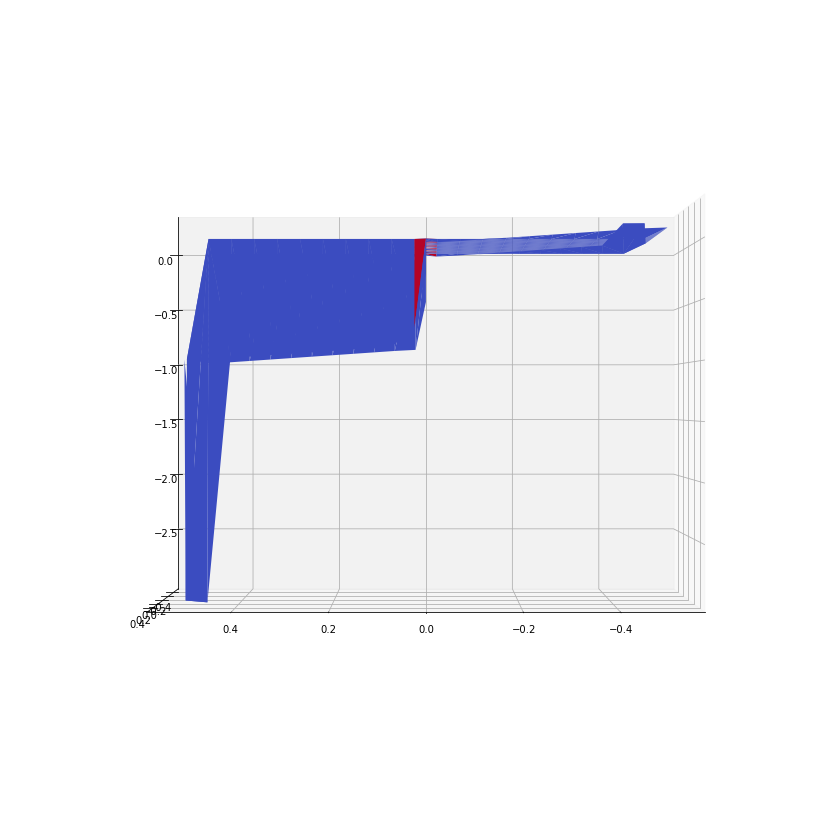

In [31]:
n = 0
A = A_matrices[n]
b = b_vectors[n]
ddr.plot_solution(Meshes[n], np.dot(A,u_ref)-b, elevation=0, azimuth=90)

Visualize Residual of "first block" of the system: $G+S+M_\Gamma$ 

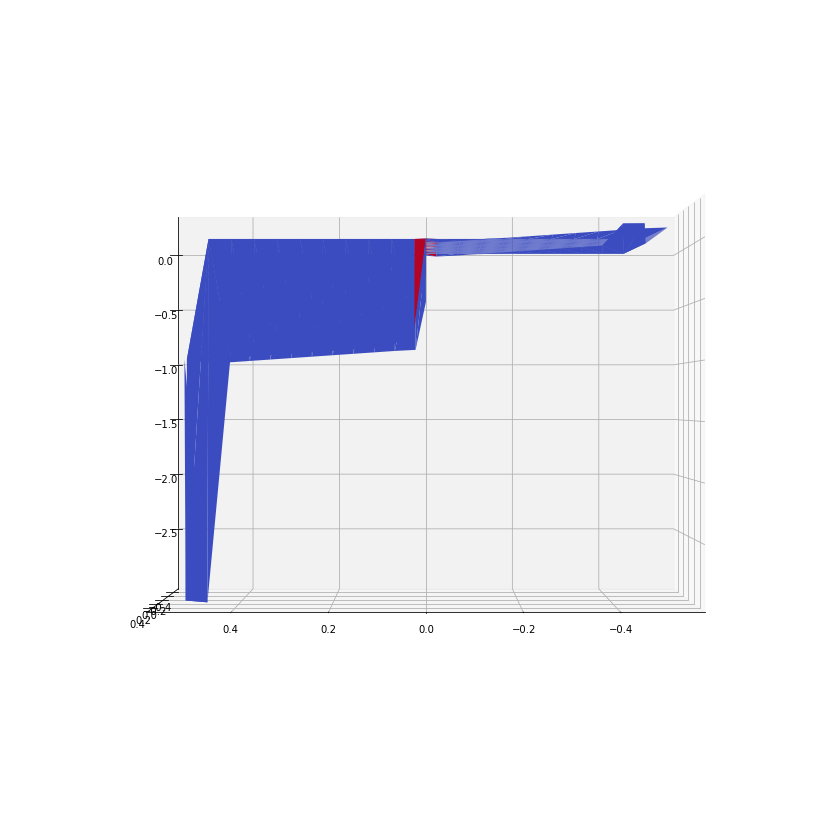

In [33]:
n = 0
G = G_matrices[n]
S = S_matrices[n]
M_gamma = M_gamma_matrices[n]
FLUX_bnd = FLUX_bnd_matrices[n]

A = G+S+np.transpose(M_gamma)-FLUX_bnd

ddr.plot_solution(Meshes[n], np.dot(A,u_ref), elevation=0, azimuth=90)

Check the quality of Gradient and Potential Reconstruction 

In [21]:
n = 0
mesh = Meshes[n]

u = np.zeros(mesh.Npoints)


for ino in range(mesh.Npoints):
    x = mesh.coords[ino,0]
    y = mesh.coords[ino,0]
    u[ino] = x + y

for ifa in range(mesh.Nfaces):
    print ("Face no:", ifa)
    node_per_face = np.count_nonzero(mesh.faces[ifa,:] != -1)
    u_F = u[mesh.faces[ifa,0:node_per_face]]
    grad = ddr.GR(mesh,ifa)
    print("Nodal values", u_F)
    print ("Gradient: ", np.dot(grad,u_F))
    R = ddr.recpot(mesh, ifa)
    print("Reconstruction", np.dot(R,u_F))
    print ("*************")
    if (np.linalg.norm( u_F- np.dot(R,u_F) )>1e-12):
        print ("Error")

Face no: 0
Nodal values [-1.        -0.9047619 -1.       ]
Gradient:  [2. 0.]
Reconstruction [-1.        -0.9047619 -1.       ]
*************
Face no: 1
Nodal values [-1.        -0.9047619 -0.9047619]
Gradient:  [2.00000000e+00 3.55271368e-15]
Reconstruction [-1.        -0.9047619 -0.9047619]
*************
Face no: 2
Nodal values [-1.        -0.9047619 -1.       ]
Gradient:  [2. 0.]
Reconstruction [-1.        -0.9047619 -1.       ]
*************
Face no: 3
Nodal values [-1.        -0.9047619 -0.9047619]
Gradient:  [2. 0.]
Reconstruction [-1.        -0.9047619 -0.9047619]
*************
Face no: 4
Nodal values [-1.        -0.9047619 -1.       ]
Gradient:  [2. 0.]
Reconstruction [-1.        -0.9047619 -1.       ]
*************
Face no: 5
Nodal values [-1.        -0.9047619 -0.9047619]
Gradient:  [2. 0.]
Reconstruction [-1.        -0.9047619 -0.9047619]
*************
Face no: 6
Nodal values [-1.        -0.9047619 -1.       ]
Gradient:  [2. 0.]
Reconstruction [-1.        -0.9047619 -1.     

Reconstruction [-0.9047619  -0.80952381 -0.9047619 ]
*************
Face no: 59
Nodal values [-0.9047619  -0.80952381 -0.80952381]
Gradient:  [2. 0.]
Reconstruction [-0.9047619  -0.80952381 -0.80952381]
*************
Face no: 60
Nodal values [-0.9047619  -0.80952381 -0.9047619 ]
Gradient:  [2.00000000e+00 1.41156927e-15]
Reconstruction [-0.9047619  -0.80952381 -0.9047619 ]
*************
Face no: 61
Nodal values [-0.9047619  -0.80952381 -0.80952381]
Gradient:  [2. 0.]
Reconstruction [-0.9047619  -0.80952381 -0.80952381]
*************
Face no: 62
Nodal values [-0.9047619  -0.80952381 -0.9047619 ]
Gradient:  [2.00000000e+00 8.77604867e-16]
Reconstruction [-0.9047619  -0.80952381 -0.9047619 ]
*************
Face no: 63
Nodal values [-0.9047619  -0.80952381 -0.80952381]
Gradient:  [2. 0.]
Reconstruction [-0.9047619  -0.80952381 -0.80952381]
*************
Face no: 64
Nodal values [-0.9047619  -0.80952381 -0.9047619 ]
Gradient:  [ 2.00000000e+00 -1.53845191e-15]
Reconstruction [-0.9047619  -0.8

Reconstruction [-0.80952381 -0.71428571 -0.80952381]
*************
Face no: 113
Nodal values [-0.80952381 -0.71428571 -0.71428571]
Gradient:  [2. 0.]
Reconstruction [-0.80952381 -0.71428571 -0.71428571]
*************
Face no: 114
Nodal values [-0.80952381 -0.71428571 -0.80952381]
Gradient:  [2.0000000e+00 8.3002388e-16]
Reconstruction [-0.80952381 -0.71428571 -0.80952381]
*************
Face no: 115
Nodal values [-0.80952381 -0.71428571 -0.71428571]
Gradient:  [2. 0.]
Reconstruction [-0.80952381 -0.71428571 -0.71428571]
*************
Face no: 116
Nodal values [-0.80952381 -0.71428571 -0.80952381]
Gradient:  [ 2.00000000e+00 -3.54214013e-16]
Reconstruction [-0.80952381 -0.71428571 -0.80952381]
*************
Face no: 117
Nodal values [-0.80952381 -0.71428571 -0.71428571]
Gradient:  [2. 0.]
Reconstruction [-0.80952381 -0.71428571 -0.71428571]
*************
Face no: 118
Nodal values [-0.80952381 -0.71428571 -0.80952381]
Gradient:  [ 2.00000000e+00 -8.61744538e-16]
Reconstruction [-0.8095238

Nodal values [-0.61904762 -0.52380952 -0.61904762]
Gradient:  [2.00000000e+00 1.95610723e-16]
Reconstruction [-0.61904762 -0.52380952 -0.61904762]
*************
Face no: 169
Nodal values [-0.61904762 -0.52380952 -0.52380952]
Gradient:  [2. 0.]
Reconstruction [-0.61904762 -0.52380952 -0.52380952]
*************
Face no: 170
Nodal values [-0.61904762 -0.52380952 -0.61904762]
Gradient:  [2.00000000e+00 7.03141249e-16]
Reconstruction [-0.61904762 -0.52380952 -0.61904762]
*************
Face no: 171
Nodal values [-0.61904762 -0.52380952 -0.52380952]
Gradient:  [2. 0.]
Reconstruction [-0.61904762 -0.52380952 -0.52380952]
*************
Face no: 172
Nodal values [-0.61904762 -0.52380952 -0.61904762]
Gradient:  [2.00000000e+00 5.92118946e-16]
Reconstruction [-0.61904762 -0.52380952 -0.61904762]
*************
Face no: 173
Nodal values [-0.61904762 -0.52380952 -0.52380952]
Gradient:  [2. 0.]
Reconstruction [-0.61904762 -0.52380952 -0.52380952]
*************
Face no: 174
Nodal values [-0.61904762 -0

Reconstruction [-0.52380952 -0.42857143 -0.42857143]
*************
Face no: 230
Nodal values [-0.52380952 -0.42857143 -0.52380952]
Gradient:  [ 2.00000000e+00 -1.04678171e-15]
Reconstruction [-0.52380952 -0.42857143 -0.52380952]
*************
Face no: 231
Nodal values [-0.52380952 -0.42857143 -0.42857143]
Gradient:  [2. 0.]
Reconstruction [-0.52380952 -0.42857143 -0.42857143]
*************
Face no: 232
Nodal values [-0.52380952 -0.42857143 -0.52380952]
Gradient:  [ 2.00000000e+00 -2.22044605e-16]
Reconstruction [-0.52380952 -0.42857143 -0.52380952]
*************
Face no: 233
Nodal values [-0.52380952 -0.42857143 -0.42857143]
Gradient:  [2. 0.]
Reconstruction [-0.52380952 -0.42857143 -0.42857143]
*************
Face no: 234
Nodal values [-0.52380952 -0.42857143 -0.52380952]
Gradient:  [ 2.00000000e+00 -4.54662762e-16]
Reconstruction [-0.52380952 -0.42857143 -0.52380952]
*************
Face no: 235
Nodal values [-0.52380952 -0.42857143 -0.42857143]
Gradient:  [2. 0.]
Reconstruction [-0.523

...

Face no: 698
Nodal values [0.52380952 0.61904762 0.52380952]
Gradient:  [ 2.00000000e+00 -8.67031314e-16]
Reconstruction [0.52380952 0.61904762 0.52380952]
*************
Face no: 699
Nodal values [0.52380952 0.61904762 0.61904762]
Gradient:  [2. 0.]
Reconstruction [0.52380952 0.61904762 0.61904762]
*************
Face no: 700
Nodal values [0.52380952 0.61904762 0.52380952]
Gradient:  [ 2.00000000e+00 -6.34413157e-17]
Reconstruction [0.52380952 0.61904762 0.52380952]
*************
Face no: 701
Nodal values [0.52380952 0.61904762 0.61904762]
Gradient:  [2. 0.]
Reconstruction [0.52380952 0.61904762 0.61904762]
*************
Face no: 702
Nodal values [0.52380952 0.61904762 0.52380952]
Gradient:  [2.00000000e+00 5.04887137e-16]
Reconstruction [0.52380952 0.61904762 0.52380952]
*************
Face no: 703
Nodal values [0.52380952 0.61904762 0.61904762]
Gradient:  [2. 0.]
Reconstruction [0.52380952 0.61904762 0.61904762]
*************
Face no: 704
Nodal values [0.52380952 0.61904762 0.52380952]

Reconstruction [0.61904762 0.71428571 0.61904762]
*************
Face no: 751
Nodal values [0.61904762 0.71428571 0.71428571]
Gradient:  [2. 0.]
Reconstruction [0.61904762 0.71428571 0.71428571]
*************
Face no: 752
Nodal values [0.61904762 0.71428571 0.61904762]
Gradient:  [ 2.00000000e+00 -1.11022302e-16]
Reconstruction [0.61904762 0.71428571 0.61904762]
*************
Face no: 753
Nodal values [0.61904762 0.71428571 0.71428571]
Gradient:  [2. 0.]
Reconstruction [0.61904762 0.71428571 0.71428571]
*************
Face no: 754
Nodal values [0.61904762 0.71428571 0.61904762]
Gradient:  [ 2.0000000e+00 -7.8772967e-16]
Reconstruction [0.61904762 0.71428571 0.61904762]
*************
Face no: 755
Nodal values [0.61904762 0.71428571 0.71428571]
Gradient:  [ 2.00000000e+00 -1.77635684e-15]
Reconstruction [0.61904762 0.71428571 0.71428571]
*************
Face no: 756
Nodal values [0.71428571 0.80952381 0.71428571]
Gradient:  [ 2.0000000e+00 -7.2957513e-16]
Reconstruction [0.71428571 0.8095238

Nodal values [0.80952381 0.9047619  0.9047619 ]
Gradient:  [2. 0.]
Reconstruction [0.80952381 0.9047619  0.9047619 ]
*************
Face no: 812
Nodal values [0.80952381 0.9047619  0.80952381]
Gradient:  [2.00000000e+00 1.39570895e-15]
Reconstruction [0.80952381 0.9047619  0.80952381]
*************
Face no: 813
Nodal values [0.80952381 0.9047619  0.9047619 ]
Gradient:  [ 2.00000000e+00 -3.55271368e-15]
Reconstruction [0.80952381 0.9047619  0.9047619 ]
*************
Face no: 814
Nodal values [0.80952381 0.9047619  0.80952381]
Gradient:  [2.00000000e+00 1.07850237e-15]
Reconstruction [0.80952381 0.9047619  0.80952381]
*************
Face no: 815
Nodal values [0.80952381 0.9047619  0.9047619 ]
Gradient:  [2. 0.]
Reconstruction [0.80952381 0.9047619  0.9047619 ]
*************
Face no: 816
Nodal values [0.80952381 0.9047619  0.80952381]
Gradient:  [2.00000000e+00 1.39570895e-15]
Reconstruction [0.80952381 0.9047619  0.80952381]
*************
Face no: 817
Nodal values [0.80952381 0.9047619  0.

Reconstruction [0.9047619 1.        1.       ]
*************
Face no: 870
Nodal values [0.9047619 1.        0.9047619]
Gradient:  [2.00000000e+00 1.56488579e-15]
Reconstruction [0.9047619 1.        0.9047619]
*************
Face no: 871
Nodal values [0.9047619 1.        1.       ]
Gradient:  [2. 0.]
Reconstruction [0.9047619 1.        1.       ]
*************
Face no: 872
Nodal values [0.9047619 1.        0.9047619]
Gradient:  [ 2.00000000e+00 -1.94553368e-15]
Reconstruction [0.9047619 1.        0.9047619]
*************
Face no: 873
Nodal values [0.9047619 1.        1.       ]
Gradient:  [2. 0.]
Reconstruction [0.9047619 1.        1.       ]
*************
Face no: 874
Nodal values [0.9047619 1.        0.9047619]
Gradient:  [2.00000000e+00 1.20009822e-15]
Reconstruction [0.9047619 1.        0.9047619]
*************
Face no: 875
Nodal values [0.9047619 1.        1.       ]
Gradient:  [2. 0.]
Reconstruction [0.9047619 1.        1.       ]
*************
Face no: 876
Nodal values [0.9047619 

Reconstruction [-2.11636264e-17 -4.12864187e-17 -4.76190476e-02 -4.76190476e-02]
*************
Face no: 920
Nodal values [-3.46944695e-17  0.00000000e+00 -4.76190476e-02]
Gradient:  [ 2.00000000e+00 -1.94445556e-31]
Reconstruction [-4.09260916e-17 -4.95596352e-18 -4.76190476e-02]
*************
Face no: 921
Nodal values [ 0.00000000e+00 -3.46944695e-17  4.76190476e-02  4.76190476e-02]
Gradient:  [ 2.0000000e+00 -6.9388939e-17]
Reconstruction [ 1.73472348e-18 -2.77555756e-17  4.76190476e-02  4.76190476e-02]
*************
Face no: 922
Nodal values [0.         0.         0.04761905]
Gradient:  [2. 0.]
Reconstruction [-3.54387829e-18 -1.87143190e-17  4.76190476e-02]
*************
Face no: 923
Nodal values [ 0.          0.         -0.04761905 -0.04761905]
Gradient:  [2. 0.]
Reconstruction [ 8.67361738e-18  5.20417043e-18 -4.76190476e-02 -4.76190476e-02]
*************
Face no: 924
Nodal values [ 0.          0.         -0.04761905]
Gradient:  [2. 0.]
Reconstruction [ 7.52993979e-18  8.60231039

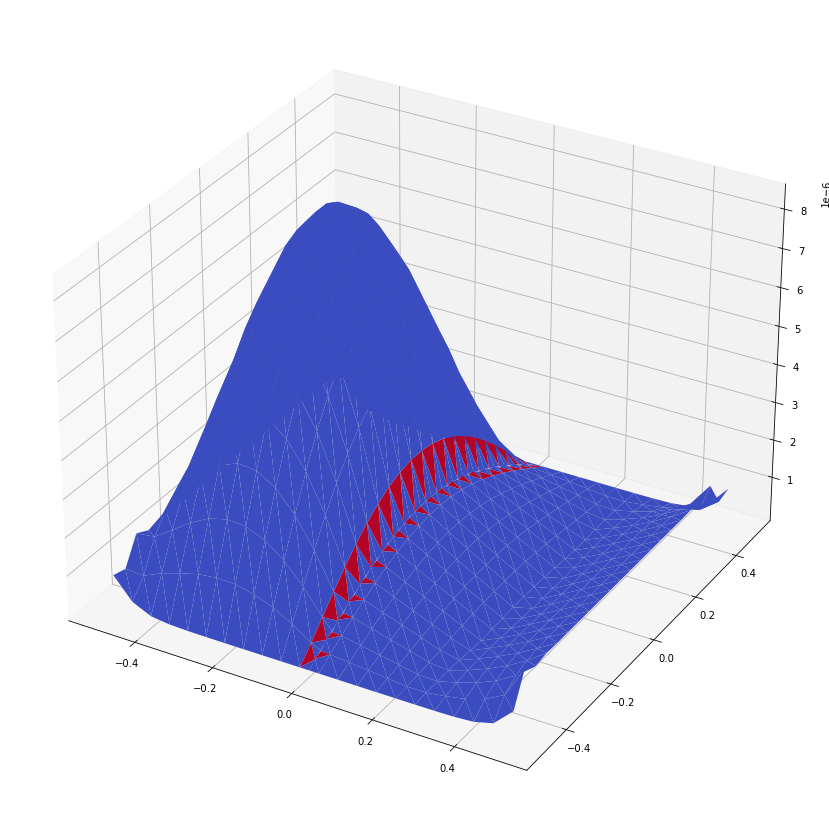

Error:  8.456552058555555e-06


In [22]:
#VISUALIZATION OF ERROR
n = 0
mesh = Meshes[n]
u = solutions[n]
u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]

# define u_ref exactely as done in routine impose_bc
#def def_u_ref (mesh,u_ref, ref_sol):
#    for dof in range(mesh.Ndof):
#        if (dof<mesh.Npoints):
#            ino = dof
#        else:
#            ino = dof-(mesh.Npoints-mesh.Npoints_init)
#        if (mesh.bnd_mask[ino]>0):
#            u_ref[dof] = ref_sol(mesh,dof)
#u_ref = np.zeros(mesh.Ndof)
#def_u_ref(mesh, u_ref, ref_sol)        

ddr.plot_solution(mesh, np.abs(u_ref-u), elevation=30, azimuth=-60)
print ("Error: ", ddr.calc_L0_error(mesh,u,ref_sol))

visualize error on Boundary Condition

## NEUMANN CONDS VERSION

In [18]:
def mark_bnd_points(mesh): # order to avoid overwriting corners
    # boundary mask, code:
    # 0: internal
    # 1: x=-0.5
    # 2: y=-0.5
    # 3: x= 0.5
    # 4: y= 0.5
    for ino in range(mesh.Npoints):
        if (abs(mesh.coords[ino,1]+0.5)<1e-6):
            mesh.bnd_mask[ino] = 2
        if (abs(mesh.coords[ino,1]-0.5)<1e-6):
            mesh.bnd_mask[ino] = 4
        if (abs(mesh.coords[ino,0]+0.5)<1e-6):
            mesh.bnd_mask[ino]= 1
        if (abs(mesh.coords[ino,0]-0.5)<1e-6):
            mesh.bnd_mask[ino] = 3


def impose_bc(mesh,A,b,ref_sol):
    for dof in range(mesh.Ndof):
        if (dof<mesh.Npoints):
            ino = dof
        else:
            ino = dof-(mesh.Npoints-mesh.Npoints_init)
        if (mesh.bnd_mask[ino]%2>0):
            b[dof] = ref_sol(mesh,dof)
            A[dof,:] = 0.0
            A[dof,dof] = 1
    return [A,b]


In [21]:
# CONVERGENCE STUDY: Solve problem for each mesh in the sequence and record error 
size_list = [5, 10, 20, 40, 80]
mesh_filenames = ["square_struc_L1_N"+str(size)+".msh" for size in size_list]
Meshes = []
G_matrices = []
G_no_sigma_matrices = []
S_matrices =[]
M_gamma_matrices = []
N_gamma_matrices = []
b_phi_vectors = []
A_matrices = []
b_vectors = []
solutions = []
errors_L0 = []
errors_energy = []
solution_filenames = ["square_struc_L1_N"+str(size)+".vtk" for size in size_list]

for (i,N) in enumerate (size_list):
    
    # load mesh
    mesh = load_square_struc_mesh(mesh_filenames[i]) # adapted for structured mesh
    # move critical points near the interface
    ddr.move_critical_points_1D(mesh) 
    # break mesh
    ddr.break_mesh_1D(mesh)
    # mark boundaries
    mark_bnd_points(mesh) # version of the test
    # assemble system
    G = ddr.assemble_G(mesh, sigma_min,sigma_plus)
    G_no_sigma = ddr.assemble_G_no_sigma(mesh) 
    S = ddr.assemble_S(mesh) 
    M_gamma = ddr.assemble_M_gamma(mesh,sigma_min,sigma_plus)
    N_gamma = ddr.assemble_N_gamma(mesh)
    b_phi = ddr.assemble_b_phi(mesh,phi_datum)
    # define system, apply bc conds an solve
    A = G+S+eta*N_gamma+np.transpose(M_gamma) # system matrix
    #A = G+S+eta*N_gamma-M_gamma 
    b = eta*b_phi
    [A, b] = impose_bc(mesh, A, b, ref_sol)
    u = np.linalg.solve(A, b)
    # write solution
    ddr.write_VTK_file(mesh, u, solution_filenames[i])
    # calculate error
    err_L0 = ddr.calc_L0_error(mesh, u, ref_sol)
    err_energy = ddr.calc_energy_error(mesh, u, ref_sol, G_no_sigma, N_gamma, S)
    # register 
    Meshes.append(mesh)
    G_matrices.append(G)
    G_no_sigma_matrices.append(G_no_sigma)
    S_matrices.append(S)
    M_gamma_matrices.append(M_gamma)
    N_gamma_matrices.append(N_gamma)
    b_phi_vectors.append(b_phi)
    A_matrices.append(A)
    b_vectors.append(b)
    solutions.append(u)
    errors_L0.append(err_L0)
    errors_energy.append(err_energy)

[-1.99086918 -1.24852164 -1.41376628 -1.597835  ]


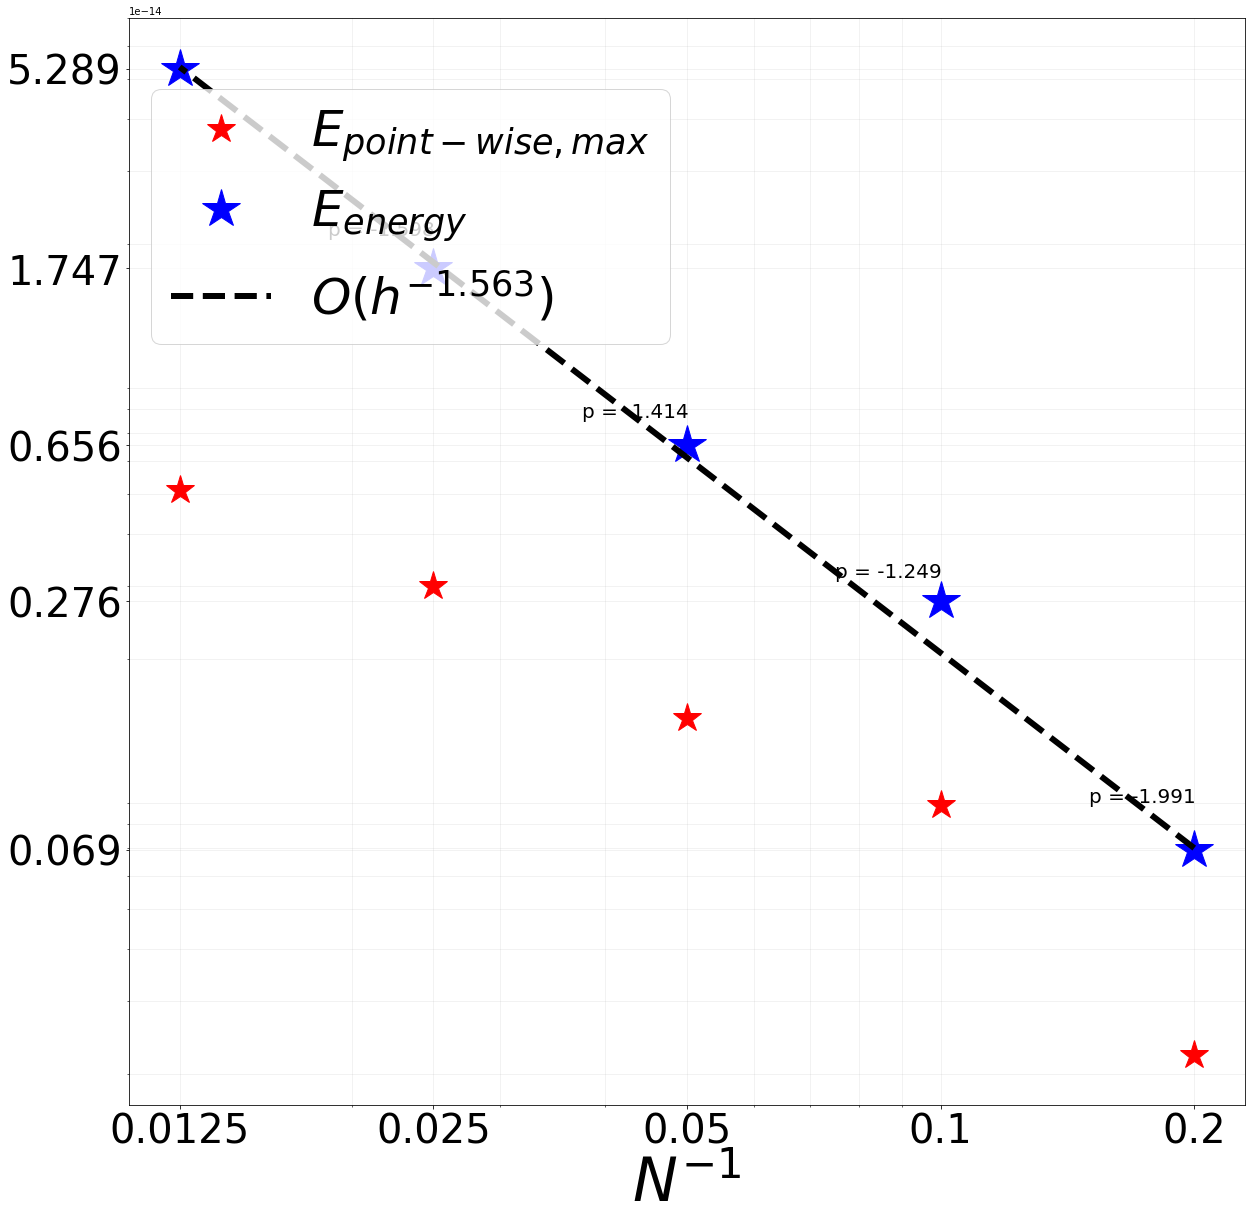

In [24]:
legend_size = 60
label_size = 40
fig_size = 20
line_width = 6
axis_name_size = 60
marker_size = 30

N = 5

fig,ax = plt.subplots(figsize=(fig_size,fig_size))
h = [1/N for N in size_list]
h_sq = [k*k for k in h]


solutions_ref = [np.array([ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]) for mesh in Meshes]
#errors_L2 = [np.linalg.norm(u-u_ref)/u.shape[0] for (u, u_ref) in zip(solutions, solutions_ref)]


ax.loglog(h,errors_L0, '*', label="$E_{point-wise,max}$", markersize = marker_size, color="red")
ax.loglog(h,errors_energy, '*', label="$E_{energy}$", markersize = marker_size+10, color="blue")
#ax.loglog(h,errors_L2, '*', label="$E_{L2}$", markersize = marker_size, color="green")
#ax.loglog(h,h/np.mean(h)*np.mean(errors_energy),'--', label="$O(N^{-1})$", color="black", linewidth= line_width )
#ax.loglog(h,h_sq/np.mean(h)*np.mean(errors_energy),'--', label="$O(N^{-2})$", color="black", linewidth= line_width )
# estimate and plot order of convergence
orders = (np.log(errors_energy[1:])-np.log(errors_energy[0:N-1]))/ (np.log(h[1:])-np.log(h[0:N-1]))
p = np.mean(orders)
h_p = [np.power(k,p) for k in h]
ax.loglog(h,h_p/np.mean(h_p)*np.mean(errors_energy),'--', label="$O(h^{"+str(np.round(p,3))+"})$", color="black", linewidth= line_width )
# print 
for i in range(len(size_list)-1):
    text = "p = "+str(np.round(orders[i],3))
    pos_x = 0.5*(h[i+1]+h[i])
    pos_y = 0.5*(errors_energy[i+1]+errors_energy[i]) - 0.4*(errors_energy[i+1]-errors_energy[i])
    ax.text(pos_x, pos_y, text, fontsize=20, color='black')

# Customize tick formatting
#plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().xaxis.set_major_locator(ticker.FixedLocator(h))
plt.gca().xaxis.set_minor_formatter(NullFormatter())
plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().yaxis.set_minor_formatter(NullFormatter())

# Set the ticks at each data point
plt.xticks(h,h)
plt.yticks(errors_energy) 

#ax.get_xaxis().get_major_formatter().labelOnlyBase = False
ax.tick_params(axis='x', which='both', labelsize=label_size)
ax.tick_params(axis='y', which='both', labelsize=label_size)
ax.set_xticks(h)

#grid
ax.grid(alpha=0.2,which='both')

# legend and axis label
legend = ax.legend(prop={'size': legend_size-10},loc=(0.02,0.7)) 
ax.set_xlabel('$N^{-1}$',fontsize=axis_name_size)
#ax.set_ylabel('$$',fontsize=axis_name_size) 
# tick setting

#plt.show()
plt.savefig('L0_convergence.png')
ax.grid('on')

print (orders)

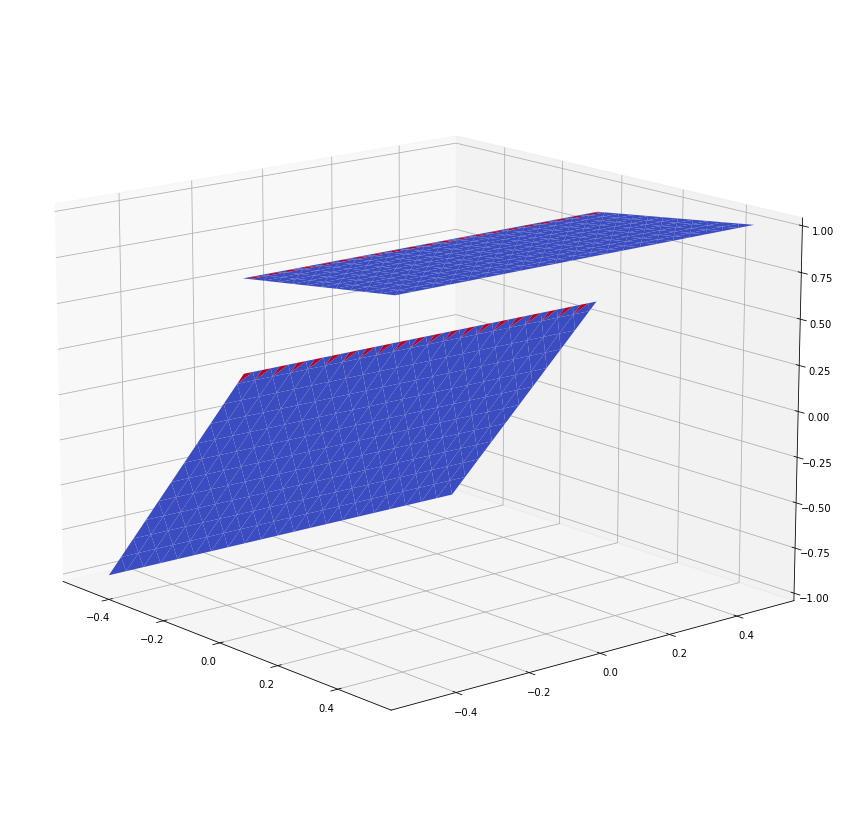

Error:  2.971898633990729e-13


In [23]:
n = 2
G_no_sigma = G_no_sigma_matrices[n]
N_gamma = N_gamma_matrices[n]
S = S_matrices[n]
ddr.plot_solution(Meshes[n], solutions[n], elevation=15, azimuth=-40)
print ("Error: ", ddr.calc_energy_error(Meshes[n],solutions[n],ref_sol, G_no_sigma, N_gamma, S))

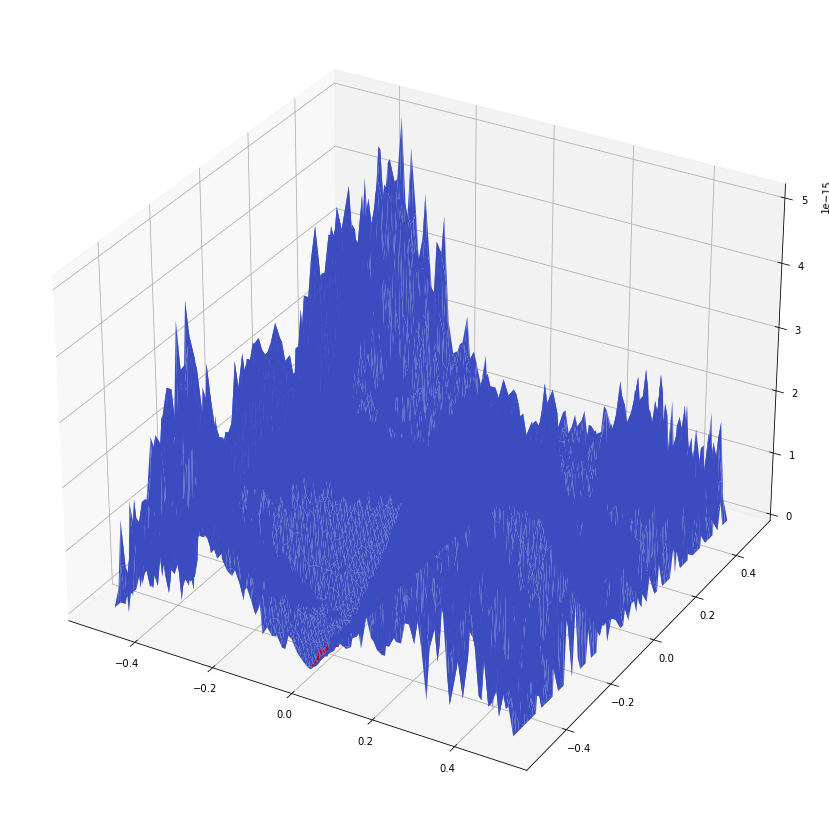

Error:  0.0


In [26]:
#VISUALIZATION OF ERROR
n = 4
mesh = Meshes[n]
u = solutions[n]
u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]

# define u_ref exactely as done in routine impose_bc
#def def_u_ref (mesh,u_ref, ref_sol):
#    for dof in range(mesh.Ndof):
#        if (dof<mesh.Npoints):
#            ino = dof
#        else:
#            ino = dof-(mesh.Npoints-mesh.Npoints_init)
#        if (mesh.bnd_mask[ino]>0):
#            u_ref[dof] = ref_sol(mesh,dof)
#u_ref = np.zeros(mesh.Ndof)
#def_u_ref(mesh, u_ref, ref_sol)        

ddr.plot_solution(mesh, np.abs(u_ref-u), elevation=30, azimuth=-60)
print ("Error: ", ddr.calc_L0_error(mesh,u_ref,ref_sol))

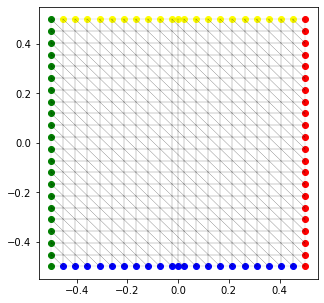

In [20]:
# CHECK BOUNDARY MASK

def visualize_bnd_points_with_dof(mesh):
    fig, ax = plt.subplots(figsize=(5,5))
    for ifa in range(mesh.Nfaces):
        if (mesh.cut_faces[ifa]!=1):
            if (mesh.faces[ifa,3]==-1):
                nvert = 3
            else:
                nvert = 4
            for ino in range(nvert):
               p1 = mesh.coords[mesh.faces[ifa,ino],:]
               p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
               dx = p2-p1
               xx = [p1[0],p2[0]]
               yy = [p1[1],p2[1]]
               ax.plot(xx,yy,'k', linewidth=0.1)
    # mark generated points
    for dof in range(mesh.Npoints):
        if (dof<mesh.Npoints):
            ino = dof
        else:
            ino = dof-(mesh.Npoints-mesh.Npoints_init)
        if (mesh.bnd_mask[ino]>0):
            xx = mesh.coords[ino,0]
            yy = mesh.coords[ino,1]
            if (mesh.bnd_mask[ino]==1):
                point = ax.scatter(xx,yy,color='green')
            if (mesh.bnd_mask[ino]==2):
                point = ax.scatter(xx,yy,color='blue')
            if (mesh.bnd_mask[ino]==3):
                point = ax.scatter(xx,yy,color='red')
            if (mesh.bnd_mask[ino]==4):
                point = ax.scatter(xx,yy,color='yellow')
    
visualize_bnd_points_with_dof(Meshes[2])